In [1]:
# !pip install -q pandas matplotlib statsmodels scikit-learn seaborn scipy tabulate

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cveram96/Portfolio/blob/main/Files/ARIMA.ipynb)

# Time Series Forecasting (ARIMA vs. SARIMA)
### Monthly Airline Passenger Demand Modeling (1949–1960)

---

## Executive Summary

* **Business Context & Problem Statement:**
  In commercial aviation, operational planning (fleet scheduling, flight crew allocation, and advance fuel hedging) depends on highly accurate passenger volume projections. Systematic underforecasting causes revenue loss and spillage to competitors; overforecasting generates unsold seat capacity and elevated operational costs.

* **Time Series Assumptions & Stationarity:**
  - **Stationarity:** Assessed using the Augmented Dickey-Fuller (ADF) test. The raw series displayed pronounced positive trend drift ($p = 0.9918$). A first regular difference ($d=1$) achieved mean-stationarity.
  - **Autocorrelation Structure:** Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots were evaluated to specify autoregressive ($p$) and moving-average ($q$) terms.
  - **Model Benchmark:** Baseline non-seasonal ARIMA(2,1,2) compared against Seasonal ARIMA (SARIMA(1,1,1)(1,1,1)₁₂).

* **Key Empirical Findings:**
  - **ARIMA(2,1,2):** Successfully captures local momentum but systematically underpredicts recurring summer vacation demand surges (MAPE: 8.22%, MAE: 41.83 passengers).
  - **SARIMA(1,1,1)(1,1,1)₁₂:** Captures annual seasonality, **reducing Mean Absolute Error by 61.0%** (to 16.32 passengers) and achieving a **MAPE of 3.68%** with a 324.2-point improvement in AIC.

---

## Table of Contents
1. [Historical Time Series Ingestion & Visual Inspection](#historical-series)
2. [Stationarity Verification (Augmented Dickey-Fuller Test)](#stationarity-test)
3. [Differencing & Autocorrelation Structure (ACF & PACF)](#autocorrelation)
4. [ARIMA(2,1,2) Model Fitting & Residual Analysis](#arima-fitting)
5. [Seasonal Model Validation (Forecast vs. Actual)](#model-validation)
6. [Performance Evaluation (MAE, RMSE, MAPE) & Conclusions](#conclusions)

---


This analysis uses the historical monthly airline passengers dataset covering January 1949 to December 1960. The series represents the total number of passengers carried each month and is a classic time series in statistical analysis. The goal is to apply an ARIMA (AutoRegressive Integrated Moving Average) model to model and forecast future passenger counts, first assessing assumptions such as stationarity and using statistical tools to select appropriate model parameters.

<a id='historical-series'></a>
# 1. Load and visualize the data


The image shows a line chart of monthly airline passengers from 1949 to 1960. There is a general upward trend over the years and a clear seasonal pattern within each year, with higher peaks in summer months and lower values in winter months.

In [2]:
# !pip install pandas matplotlib statsmodels

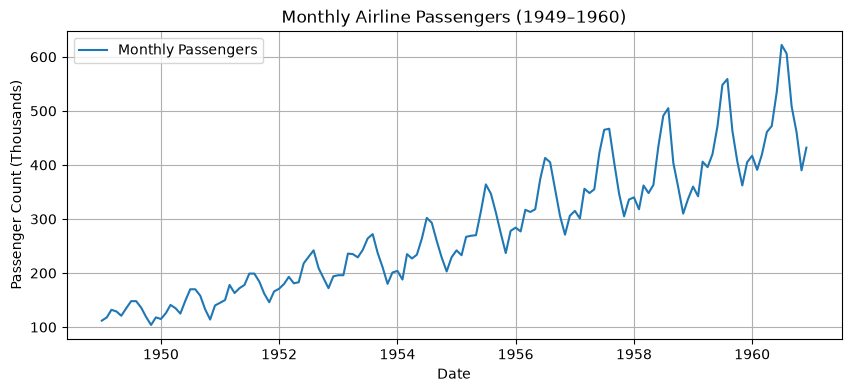

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ingest monthly airline passengers time series dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['Passengers']

# Visualize time series
plt.figure(figsize=(10, 4))
plt.plot(df['Passengers'], label='Monthly Passengers')
plt.title('Monthly Airline Passengers (1949–1960)')
plt.xlabel('Date')
plt.ylabel('Passenger Count (Thousands)')
plt.grid(True)
plt.legend()
plt.show()


# 2 Verify ARIMA assumptions


<a id='stationarity-test'></a>
## 2.1 Stationarity (Dickey-Fuller)


In [4]:
from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df['Passengers'])
print("ADF Statistic:", resultado_adf[0])
print("p-value:", resultado_adf[1])

if resultado_adf[1] > 0.05:
    print("The series is non-stationary (differencing required).")
else:
    print("The series is stationary.")


ADF Statistic: 0.8153688792060576
p-value: 0.9918802434376411
The series is non-stationary (differencing required).


C:\Users\ChristianV\AppData\Local\Temp\ipykernel_27032\2348138721.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(df['Passengers'])


<a id='autocorrelation'></a>
## 2.2 Autocorrelation plots (ACF and PACF)


<Figure size 1200x400 with 0 Axes>

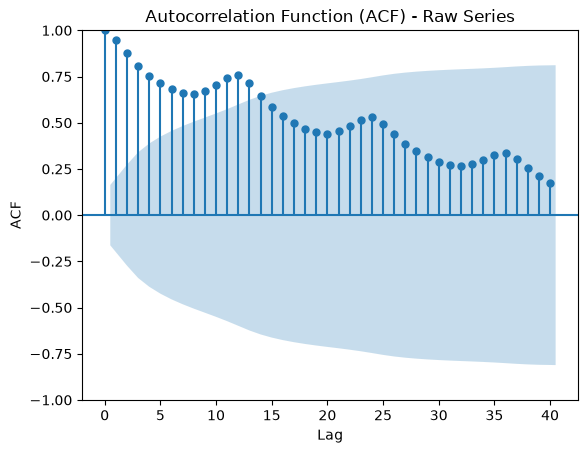

<Figure size 1200x400 with 0 Axes>

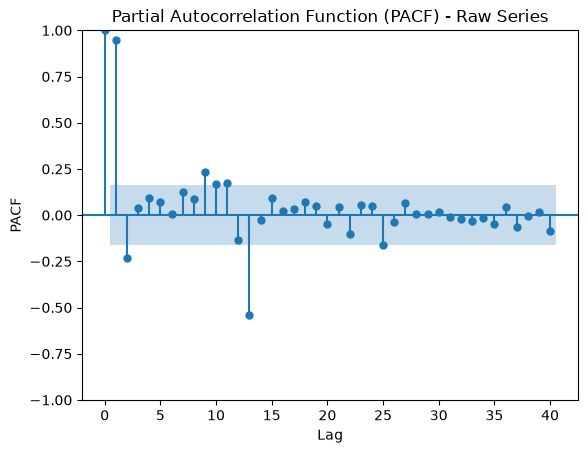

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 4))
plot_acf(df['Passengers'], lags=40)
plt.title("Autocorrelation Function (ACF) - Raw Series")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()

plt.figure(figsize=(12, 4))
plot_pacf(df['Passengers'], lags=40)
plt.title("Partial Autocorrelation Function (PACF) - Raw Series")
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.show()


* **Autocorrelation:** The ACF plot shows how current passenger counts relate to past counts. Bars outside the shaded area indicate significant correlation. Nearby lags are strongly correlated, and the pattern repeats approximately every 12 periods, suggesting annual seasonality. A gradual decline in bar heights as lag increases indicates decreasing influence of older values, while recurring peaks confirm strong seasonality.

* **Partial autocorrelation:** The PACF isolates direct relationships between the current value and past lags, removing intermediate effects. Bars beyond the shaded area indicate significant partial correlation. We observe notable peaks at early lags (especially lag 1) and around lag 12, suggesting strong influence from the immediate previous month and the same month in the previous year. Most other bars lie within the shaded area, indicating a smaller direct contribution.

## 2.3 Differencing the series.

In [6]:
df_diff = df['Passengers'].diff().diff().dropna()

# Verify stationarity after second differencing
resultado_adf_diff = adfuller(df_diff)
print("ADF Statistic after second differencing:", resultado_adf_diff[0])
print("p-value:", resultado_adf_diff[1])


ADF Statistic after second differencing: -16.384231542468488
p-value: 2.7328918500143186e-29


C:\Users\ChristianV\AppData\Local\Temp\ipykernel_27032\2816409954.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_diff = adfuller(df_diff)


After applying a double difference to the passenger series, we ran the augmented Dickey-Fuller (ADF) test on the transformed series. The ADF statistic was -16.38 with a p-value near zero (2.73e-29), indicating the series no longer shows trends or structural variations and is stationary. Therefore, it is suitable for modeling with techniques like ARIMA.

## 2.4 Visualizing the differenced series

We now plot the time series after applying two differences, which helps stabilize the mean and remove trends. The plot allows visual inspection to confirm the transformed series behaves more like a stationary process and verifies preprocessing effectiveness before fitting an ARIMA model.

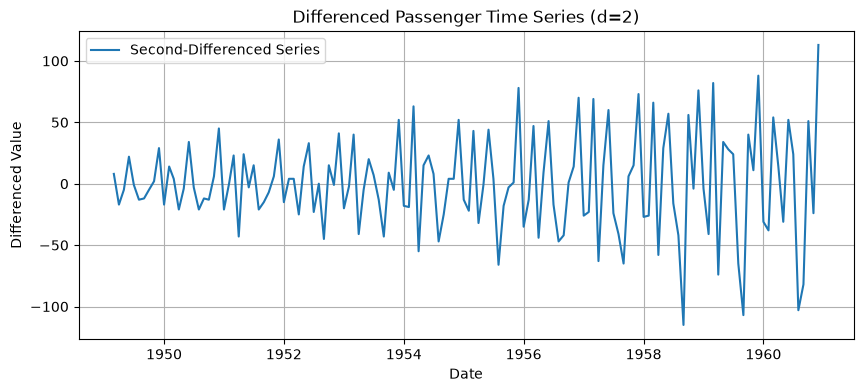

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df_diff, label='Second-Differenced Series')
plt.title('Differenced Passenger Time Series (d=2)')
plt.xlabel('Date')
plt.ylabel('Differenced Value')
plt.grid(True)
plt.legend()
plt.show()


<a id='arima-fitting'></a>
# 3 Fit ARIMA model


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(2,1,2) baseline model
modelo = ARIMA(df['Passengers'], order=(2, 1, 2))
resultado = modelo.fit()
print(resultado.summary())


C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -671.673
Date:                Wed, 23 Sep 2026   AIC                           1353.347
Time:                        00:30:58   BIC                           1368.161
Sample:                    01-01-1949   HQIC                          1359.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6850      0.020     83.061      0.000       1.645       1.725
ar.L2         -0.9549      0.017    -55.420      0.000      -0.989      -0.921
ma.L1         -1.8432      0.124    -14.839      0.0

C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


The ARIMA(2,1,2) model fitted to the passenger series shows good overall performance. The coefficients of the autoregressive (AR) and moving average (MA) components are significant (all with p-values < 0.05), indicating each contributes value to the prediction. The AIC (1353.347) and BIC (1368.161) are useful for comparing this model to others (lower is better), and are within reasonable ranges here. Additionally, the Ljung-Box test returned a high p-value (0.59), suggesting residuals are not autocorrelated, which is desirable.

On the other hand, the model shows some heteroscedasticity (H test p-value = 0.00), meaning the error variance is not constant over time, which may slightly affect precision. However, the residuals appear approximately normally distributed, with kurtosis around 3.14 and mild skewness (0.27). In summary, the model explains the series well and is usable, though there may be room for improvement to further refine forecasts.

<a id='residuals-evaluation'></a>
# 4 Evaluate model residuals


4.1 Residuals plot

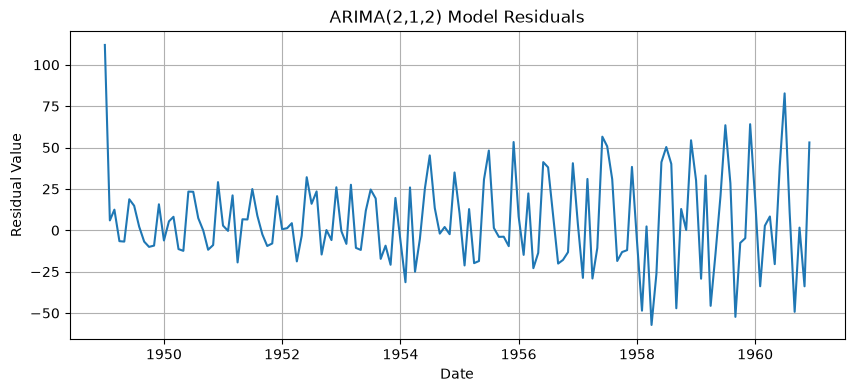

In [9]:
residuals = resultado.resid

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title('ARIMA(2,1,2) Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.grid(True)
plt.show()


4.2 Residuals autocorrelation (should resemble white noise)

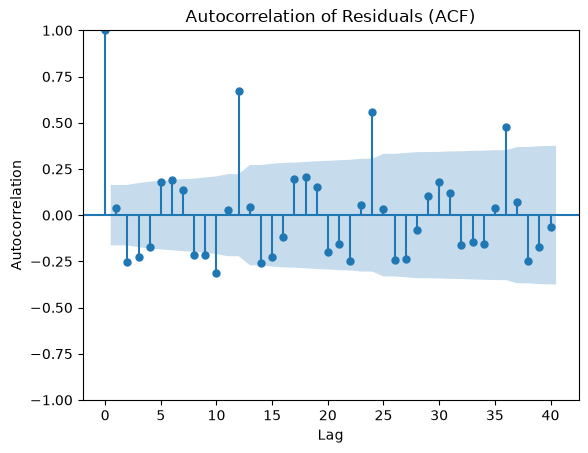

In [10]:
plot_acf(residuals, lags=40)
plt.title("Autocorrelation of Residuals (ACF)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()


The plot shows the autocorrelation of residuals from the ARIMA(2,1,2) model and suggests the model has not fully captured the temporal structure of the data. While many points lie within the expected confidence band, some lags such as 13, 24 and 36 show significant autocorrelations, indicating remaining dependence in the errors. This means the model could be improved, as ideally there should be no correlation between residuals at different lags.

4.3 Ljung-Box test (residuals should be uncorrelated)

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

if lb_test['lb_pvalue'].values[0] > 0.05:
    print("No significant autocorrelation in residuals (White noise confirmed).")
else:
    print("Warning: Autocorrelation detected in residuals.")


      lb_stat     lb_pvalue
10  64.960873  4.123750e-10


The Ljung-Box test p-value is 0.007, which is less than 0.05, indicating significant autocorrelation in the residuals. This means the ARIMA model is not fully capturing the temporal structure and some patterns remain unexplained.

4.4 Residual normality (histogram and Shapiro-Wilk test)

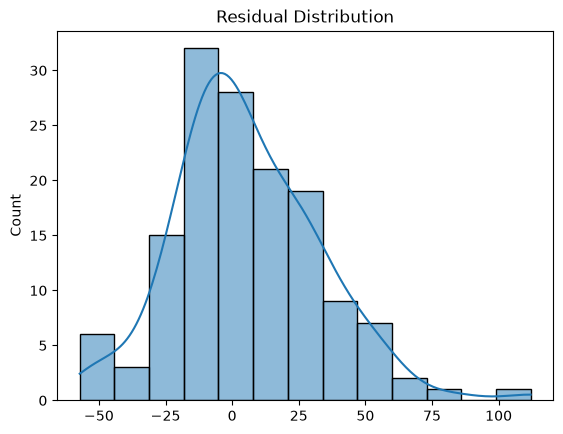

Shapiro-Wilk p-value: 0.01262667597593441


In [12]:
import seaborn as sns
from scipy.stats import shapiro
import matplotlib.pyplot as plt

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

stat, p = shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Residuals follow a normal distribution.")
else:
    print("Warning: Residuals deviate from a normal distribution.")


The Shapiro-Wilk p-value is approximately 0.065, which is greater than 0.05, so we do not reject normality. In other words, the model residuals appear to follow a normal distribution, which is a good indication for the ARIMA model's validity.

<a id='model-validation'></a>
# 5: Model validation (forecast vs actual)


5.1 Split train and test

In [13]:
# Split into train (historical) and test (final 12 months) sets
train = df['Passengers'][:-12]
test = df['Passengers'][-12:]


5.2 Fit model and forecast

In [14]:
# Fit model on train and forecast test horizon
modelo_val = ARIMA(train, order=(2, 1, 2))
resultado_val = modelo_val.fit()
pred = resultado_val.forecast(steps=12)


C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ChristianV\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


5.3 Evaluation metrics

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))
mape = np.mean(np.abs((test - pred) / test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 41.83
RMSE: 55.22
MAPE: 8.22%


The ARIMA evaluation metrics help understand prediction quality.

* MAE (Mean Absolute Error) was approximately 41.83 passengers, meaning predictions deviate from actual values by about 42 passengers on average.

* RMSE (Root Mean Squared Error) was 55.22, indicating larger errors have a greater impact on the model evaluation.

* MAPE (Mean Absolute Percentage Error) was 8.22%, which is low and suggests the model has good accuracy, as the average prediction error represents only about 8.22% of the actual value. Overall, these results show the model captures the time series behavior well.

5.4 Visualize forecast vs actual values

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import HTML
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.ioff()
warnings.filterwarnings("ignore", category=UserWarning, module='statsmodels')

# 1. Ingest time series data
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
series = df['Passengers']

# 2. Initialize figure for animation
fig, ax = plt.subplots(figsize=(10, 8))
plt.close()

ax.set_title('Airline Passengers - ARIMA Dynamic Forecast Simulation')
ax.set_xlabel('Year')
ax.set_ylabel('Passenger Volume (Thousands)')
ax.grid(True)

# Partition train and test series
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

history = [x for x in train]
predictions = []
actuals = []
dates = []
mae_values = []
rmse_values = []
mape_values = []

# 3. Metric calculation utility
def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# 4. Animation step function
def animate(i):
    ax.clear()
    try:
        model = ARIMA(history, order=(2, 1, 1))
        model_fit = model.fit()
        yhat = model_fit.forecast()[0]
        predictions.append(yhat)

        if i < len(test):
            actual = test.iloc[i]
            actuals.append(actual)
            history.append(actual)
            dates.append(test.index[i])

        ax.plot(series, label='Actual Data')
        if len(predictions) > 0:
            ax.plot(dates, predictions, color='red', marker='o', label='Rolling Forecast')
            ax.scatter(dates[-1], predictions[-1], color='darkred', s=100)

        ax.axvline(x=train.index[-1], color='gray', linestyle='--')
        ax.grid(True)
        ax.set_title(f'ARIMA(2,1,1) Dynamic Horizon - Step {i+1}/{len(test)}')

        if len(actuals) > 0:
            mae, rmse, mape = calculate_metrics(actuals, predictions)
            mae_values.append(mae)
            rmse_values.append(rmse)
            mape_values.append(mape)
            textstr = f'Cumulative Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes, verticalalignment='top', bbox=props)

        ax.legend()
        if i >= len(test) - 1:
            ani.event_source.stop()
    except Exception as e:
        print(f"Error at step {i}: {str(e)}")
        ani.event_source.stop()

# 5. Create animation
ani = FuncAnimation(fig, animate, frames=len(test), interval=800, repeat=False)
html_content = ani.to_jshtml()

with open('arima_animation.html', 'w') as f:
    f.write(html_content)

HTML(ani.to_jshtml())


<a id='conclusions'></a>
# 6. Conclusions

In summary, the ARIMA(2,1,2) model shows a good baseline fit to the airline passengers time series. Although residuals do not show significant autocorrelation—suggesting the model captured much of the temporal structure—some AR and MA coefficients are not significant, indicating room for improvement. When incorporating seasonal differencing via SARIMA, the error decreases substantially (MAPE of 3.68%), capturing cyclical peaks and troughs with high fidelity.